# Basic example 2

This MFA is very similar to the basic_example_1, but instead uses carbon content parameters instead of transfer coefficients. It basically models the harvesting process of wheat in a very simplified way.

<img src="system_flow_diagram.svg" alt="system_flow_diagram">

## 0 Load packages

In [1]:
### Load packages ###

# Load general libraries
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import lognorm
import xlsxwriter
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator,
                               FormatStrFormatter,
                               AutoMinorLocator)
import warnings
import re
from collections import defaultdict
from scipy.optimize import minimize
import copy

# Load ODYM package
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'framework', 'ODYM-master_20241127', 'odym', 'modules')) 

# Import the ODYM class file
import ODYM_Classes as msc 
# Import the ODYM function file
import ODYM_Functions as msf
# Import the dynamic stock model library
import dynamic_stock_model as dsm 


# Load bioDYM_addon
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'framework', 'bioDYM_add-on', 'modules')) 

# Import classes for first order model process
import bioDYM_classes as bicl
# Import plotting functions
import bioDYM_plotting as bipl
# Import export functions
import bioDYM_export as bix




# Enables plotting directly in the notebook (in most cases this is already enabled)
%matplotlib inline

## 1 Definition of system and relevant aspects

In [2]:
ModelClassification  = {} # Create empty dictionary of model classifications

MyYears = list(np.arange(2025,2029)) # Define period of analysis and create list of years
ModelClassification['Time'] = msc.Classification(Name = 'Time', Dimension = 'Time', ID = 1,
                                                 Items = MyYears)
# Classification for time labelled 'Time' must always be present, with Items containing a list of ordered integers representing years, months, or other discrete time intervals


ModelClassification['Element'] = msc.Classification(Name = 'Elements', Dimension = 'Element', 
                                                    ID = 2, Items = ['Biomass', 'Carbon'])
# Classification for elements labelled 'Element' must always be present, with Items containing a list of the symbols of the elements covered.
# Here, other elements (like N or P) could be added to the ODYM MFA system

# Get model time start, end, and duration:
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start


In [3]:
IndexTable = pd.DataFrame({'Aspect'        : ['Time','Element'], # 'Time' and 'Element' must be present!
                           'Description'   : ['Model aspect "time"', 'Model aspect "Element"'],
                           'Dimension'     : ['Time','Element'], # 'Time' and 'Element' are also dimensions
                           'Classification': [ModelClassification[Aspect] for Aspect in ['Time','Element']],
                           'IndexLetter'   : ['t','e']}) # Unique one letter (upper or lower case) indices to be used later for calculations.

IndexTable.set_index('Aspect', inplace = True) # Default indexing of IndexTable, other indices are produced on the fly

IndexTable #Classification refers to ODYM structure, is not relevant for using the template 

,Description,Dimension,Classification,IndexLetter
Aspect,,,,
Time,"Model aspect ""time""",Time,<ODYM_Classes.Classification object at 0x7f15e...,t
Element,"Model aspect ""Element""",Element,<ODYM_Classes.Classification object at 0x7f15e...,e


In [4]:
# Initialize MFA system
Dyn_MFA_System = msc.MFAsystem(Name = 'TestSystem', 
                      Geogr_Scope = 'TestRegion', 
                      Unit = 'Mg', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = {}, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) 

In [5]:
# Define all processes and specify an ID (ID is used to assign flows and stocks to processes)
Dyn_MFA_System.ProcessList = [] 
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Environment' , ID   = 0))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Processing' , ID   = 1))
Dyn_MFA_System.ProcessList.append(msc.Process(Name = 'Food'    , ID   = 2))



In [6]:
# FlowDict 
Dyn_MFA_System.FlowDict['F_0_1'] = msc.Flow(Name = 'F_0_1', P_Start = 0, P_End = 1,
                                            Indices = 't,e', Values=None, Uncert = np.zeros(shape = (len(MyYears),len(ModelClassification['Element'].Items))))
Dyn_MFA_System.FlowDict['F_1_2'] = msc.Flow(Name = 'F_1_2', P_Start = 1, P_End = 2,
                                            Indices = 't,e', Values=None)
Dyn_MFA_System.FlowDict['F_1_0'] = msc.Flow(Name = 'F_1_0', P_Start = 1, P_End = 0,
                                            Indices = 't,e', Values=None)



# StockDict 
Dyn_MFA_System.StockDict['dS_2']  = msc.Stock(Name = 'dS_2', P_Res = 2, Type = 1,
                                              Indices = 't,e', Values=None)
Dyn_MFA_System.StockDict['S_2']   = msc.Stock(Name = 'S_2', P_Res = 2, Type = 0,
                                              Indices = 't,e', Values=None)


# Assign empty arrays to flows according to dimensions
Dyn_MFA_System.Initialize_FlowValues() 
Dyn_MFA_System.Initialize_StockValues() 

## 2 Data input into model

In [7]:
# Get biomass input data from .xlsx
file_path = 'input_data.xlsx'
input_data = pd.read_excel(file_path, header = 0)
input_data

,Year,F_0_1
0,2025,100
1,2026,110
2,2027,120
3,2028,130


In [8]:
# ParameterDict 

ParameterDict = {}


ParameterDict['F_0_1']  = msc.Parameter(Name = 'F_0_1', ID = 1, P_Res = 1,
                                         Indices = 't,e',
                                        Values = None, Unit = 't/yr')



ParameterDict['harvest_index'] = msc.Parameter(Name = 'harvest_index', ID = 3, P_Res = 1,
                                          Indices = 't,e', 
                                         Values = 0.45, Unit = '1')
# harvest_index from 
# Dai, J., Bean, B., Brown, B., Bruening, W., Edwards, J., Flowers, M., Karow, R., Lee, C., Morgan, G., Ottman, M., Ransom, J., & Wiersma, J. 
# (2016). 
# Harvest index and straw yield of five classes of wheat. 
# Biomass and Bioenergy, 85, 223–227. 
# https://doi.org/10.1016/j.biombioe.2015.12.023



ParameterDict['grain_c_content'] = msc.Parameter(Name = 'grain_c_content', ID = 3, P_Res = 1,
                                          Indices = 't,e', 
                                         Values = 0.41, Unit = '1')

ParameterDict['straw_c_content'] = msc.Parameter(Name = 'straw_c_content', ID = 3, P_Res = 1,
                                          Indices = 't,e', 
                                         Values = 0.42, Unit = '1')
# grain_c_content and straw_c_content from
# Kumar, M., Singh, R. P., Panigrahy, S., & Raghubanshi, A. 
# (2014). 
# Carbon density and accumulation in agroecosystem of Indo-Gangetic Plains and Vindhyan highlands, India. 
# Environmental Monitoring and Assessment, 186. 
# https://doi.org/10.1007/s10661-014-3752-3

# Assign parameter dictionary to MFA system:
Dyn_MFA_System.ParameterDict = ParameterDict

# Assign empty arrays to parameters according to dimensions, analogous to the procedure in FlowDict and StockDict
Dyn_MFA_System.Initialize_ParameterValues()

In [9]:
# Add all input data to ParametersDict
# Parameters, Flows and stocks have the shape (number of years, number of elements)


ParameterDict['F_0_1'].Values[:,0] = input_data['F_0_1']


for parameter in Dyn_MFA_System.ParameterDict.values():
    print(parameter.Name)
    print(parameter.Values)

F_0_1
[[100.   0.]
 [110.   0.]
 [120.   0.]
 [130.   0.]]
harvest_index
0.45
grain_c_content
0.41
straw_c_content
0.42


In [10]:
# Check whether flow value arrays match their indices, etc. See ODYM method documentation.
Dyn_MFA_System.Consistency_Check() 

(True, True, True)

## 3 MFA Calculations

In [11]:
# Calculate results based on input data

Dyn_MFA_System.FlowDict['F_0_1'].Values = Dyn_MFA_System.ParameterDict['F_0_1'].Values

Dyn_MFA_System.FlowDict['F_0_1'].Values[:, 1] = \
Dyn_MFA_System.FlowDict['F_0_1'].Values[:, 0] * \
(Dyn_MFA_System.ParameterDict['harvest_index'].Values * Dyn_MFA_System.ParameterDict['grain_c_content'].Values + \
 (1 - Dyn_MFA_System.ParameterDict['harvest_index'].Values) * Dyn_MFA_System.ParameterDict['straw_c_content'].Values)


Dyn_MFA_System.FlowDict['F_1_2'].Values[:, 0] = \
Dyn_MFA_System.FlowDict['F_0_1'].Values[:, 0] * Dyn_MFA_System.ParameterDict['harvest_index'].Values

Dyn_MFA_System.FlowDict['F_1_2'].Values[:, 1] = \
Dyn_MFA_System.FlowDict['F_1_2'].Values[:, 0] * Dyn_MFA_System.ParameterDict['grain_c_content'].Values


Dyn_MFA_System.FlowDict['F_1_0'].Values[:, 0] = \
Dyn_MFA_System.FlowDict['F_0_1'].Values[:, 0] * (1 - Dyn_MFA_System.ParameterDict['harvest_index'].Values)

Dyn_MFA_System.FlowDict['F_1_0'].Values[:, 1] = \
Dyn_MFA_System.FlowDict['F_1_0'].Values[:, 0] * Dyn_MFA_System.ParameterDict['straw_c_content'].Values





Dyn_MFA_System.StockDict['dS_2'].Values = Dyn_MFA_System.FlowDict['F_1_2'].Values

Dyn_MFA_System.StockDict['S_2'].Values = Dyn_MFA_System.StockDict['dS_2'].Values.cumsum(axis = 0)


for flow in Dyn_MFA_System.FlowDict.values():
    print(flow.Name)
    print(flow.Values)

for stock in Dyn_MFA_System.StockDict.values():
    print(stock.Name)
    print(stock.Values)



F_0_1
[[100.     41.55 ]
 [110.     45.705]
 [120.     49.86 ]
 [130.     54.015]]
F_1_2
[[45.    18.45 ]
 [49.5   20.295]
 [54.    22.14 ]
 [58.5   23.985]]
F_1_0
[[55.   23.1 ]
 [60.5  25.41]
 [66.   27.72]
 [71.5  30.03]]
dS_2
[[45.    18.45 ]
 [49.5   20.295]
 [54.    22.14 ]
 [58.5   23.985]]
S_2
[[ 45.     18.45 ]
 [ 94.5    38.745]
 [148.5    60.885]
 [207.     84.87 ]]


### 3.1.4 Final Mass balance check

In [12]:
Bal = Dyn_MFA_System.MassBalance()
print(Bal.shape) # dimensions of balance are: time step x process x element
print(np.abs(Bal).sum(axis = 0).sum(axis = 1)) # reports the sum of all absolute balancing errors by process.

(4, 3, 2)
[2.84217094e-14 2.84217094e-14 0.00000000e+00]


## 4 Presentation of results

### 4.1 Simple plots

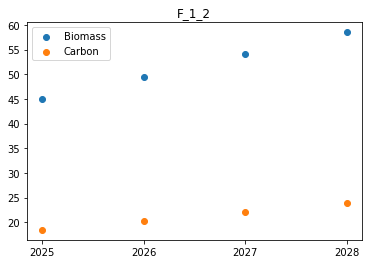

In [13]:
fig, ax = plt.subplots()

ax.scatter(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.FlowDict['F_1_2'].Values[:,0]) 
ax.scatter(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.FlowDict['F_1_2'].Values[:,1])

ax.xaxis.set_major_locator(MultipleLocator(1))

ax.set_title("F_1_2")
ax.legend(ModelClassification['Element'].Items)
plt.show()

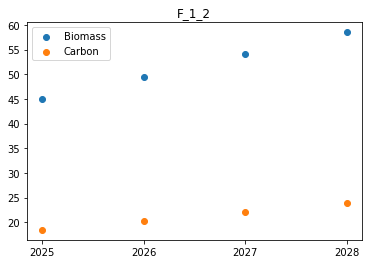

In [14]:
# Assuming the first column is Biomass and the second column is Carbon
time = Dyn_MFA_System.IndexTable['Classification']['Time'].Items
flow_values = Dyn_MFA_System.FlowDict['F_1_2'].Values
fig, ax = plt.subplots()
# Loop over columns in the flow values (Biomass, Carbon)
for i, element in enumerate(ModelClassification['Element'].Items):
    ax.scatter(time, flow_values[:, i], label=element)
# Optional: Add a legend to the plot to label each line

ax.set_title("F_1_2")
ax.legend(ModelClassification['Element'].Items)
ax.xaxis.set_major_locator(MultipleLocator(1))
plt.show()


### 4.2 Interactive Sankey diagram

In [15]:
# Here, the data of the ODYM MFA system is extracted and put into an applicable form for the interactive Sankey diagram 
# Choose colors for flows
colors_flows = []
colors_flows.extend(["darkseagreen" for i in range(2)])
colors_flows.extend(["tan" for i in range(2)])


# Choose colors for processes
colors_processes = ["darkseagreen", "darkseagreen", "darkseagreen", "tan"]


In [16]:
# Apply formula 
# If diagram does not show, try enableling the widgetsnbextension 
# by running: jupyter nbextension enable --py --sys-prefix widgetsnbextension
excluded_flows = {''}
bipl.sankey_results(Dyn_MFA_System, MyYears, ModelClassification, colors_flows, colors_processes, excluded_flows)

FigureWidget({
    'data': [{'link': {'color': [darkseagreen, darkseagreen, tan, tan],
                       'source': [0, 1, 1],
                       'target': [1, 2, 0],
                       'value': [100.0, 41.55]},
              'node': {'color': [darkseagreen, darkseagreen, darkseagreen, tan],
                       'label': [Environment, Processing, Food],
                       'line': {'color': 'black', 'width': 0.5},
                       'pad': 80,
                       'thickness': 10},
              'type': 'sankey',
              'uid': '1a7604ef-f05c-438d-b4d1-2755a7460e54'}],
    'layout': {'height': 800,
               'template': '...',
               'title': {'text': 'System Sankey diagram Biomass (years 2025-2028) [t]'},
               'width': 1000}
})

interactive(children=(Dropdown(description='element:', options=('Biomass', 'Carbon'), value='Biomass'), IntSli…

### 4.3 Interactive stock plots

In [17]:
bipl.bar_stocks_results(Dyn_MFA_System, MyYears, ModelClassification, colors_processes)

FigureWidget({
    'data': [{'marker': {'color': ['darkseagreen']},
              'type': 'bar',
              'uid': 'c1b3ead0-c660-4c34-80ca-cb8033d9f346',
              'x': [Food],
              'y': [45.0, 18.45]}],
    'layout': {'template': '...',
               'title': {'text': 'System stocks diagram Biomass (years 2025-2028) [t]'},
               'yaxis': {'range': [0, 227.70000000000002]}}
})

interactive(children=(Dropdown(description='element:', options=('Biomass', 'Carbon'), value='Biomass'), IntSli…

### 4.4 Excel export

In [18]:
bix.export_xlsx(Dyn_MFA_System, MyYears, ModelClassification)